C:\Users\PC\AppData\Local\Temp\ipykernel_12732\1384646204.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(col_mode, inplace=True)


Missing values in column 'workclass' replaced with mode 'Private'.
Missing values in column 'occupation' replaced with mode 'Prof-specialty'.
Missing values in column 'native-country' replaced with mode 'United-States'.

Number of missing values after imputation:
workclass         0
occupation        0
native-country    0
dtype: int64

Preprocessed dataset saved to ../dist/adult_to_others.csv.
Number of unique countries after merging: 24

Binarized dataset saved to ../dist/adult_binarized.csv.

Final binarized dataset saved to ../dist/adult_preprocessed.csv.


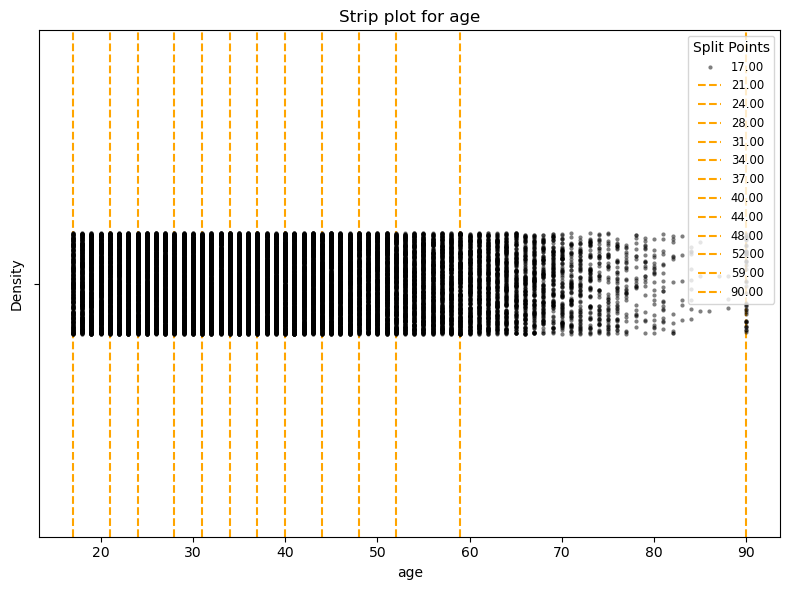

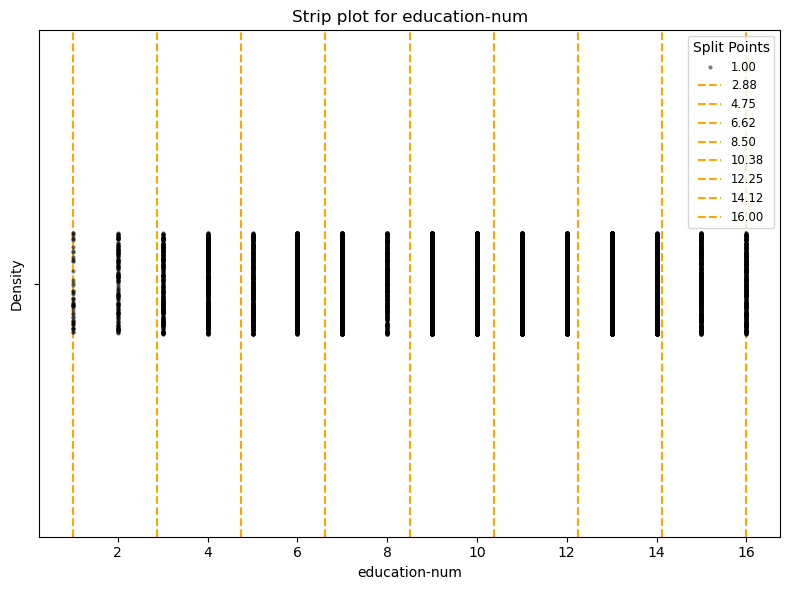

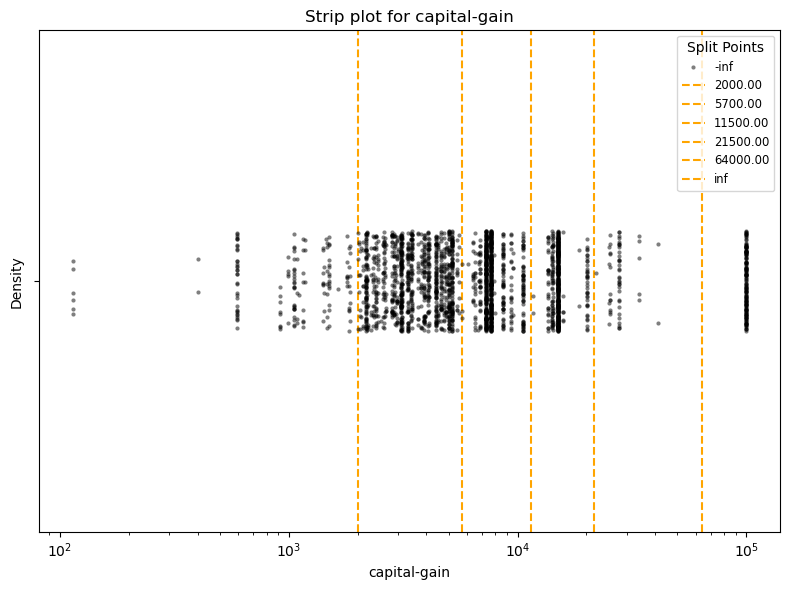

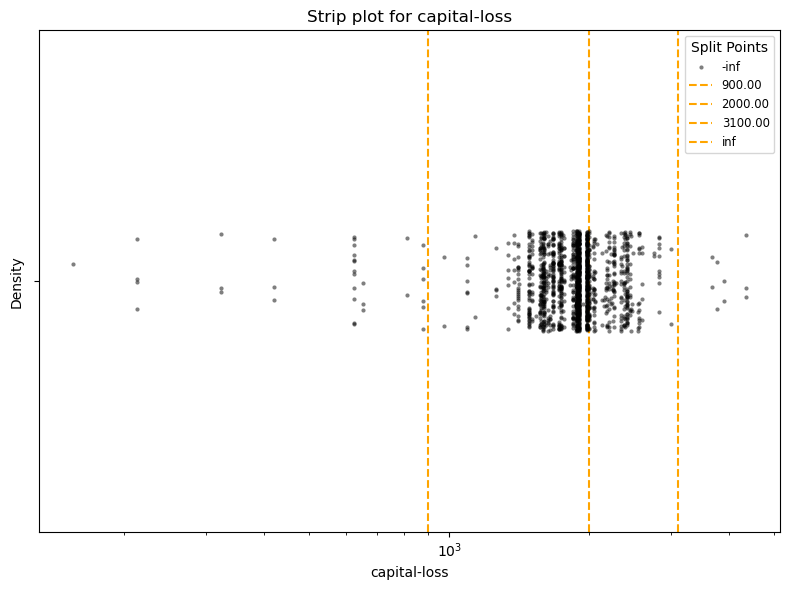

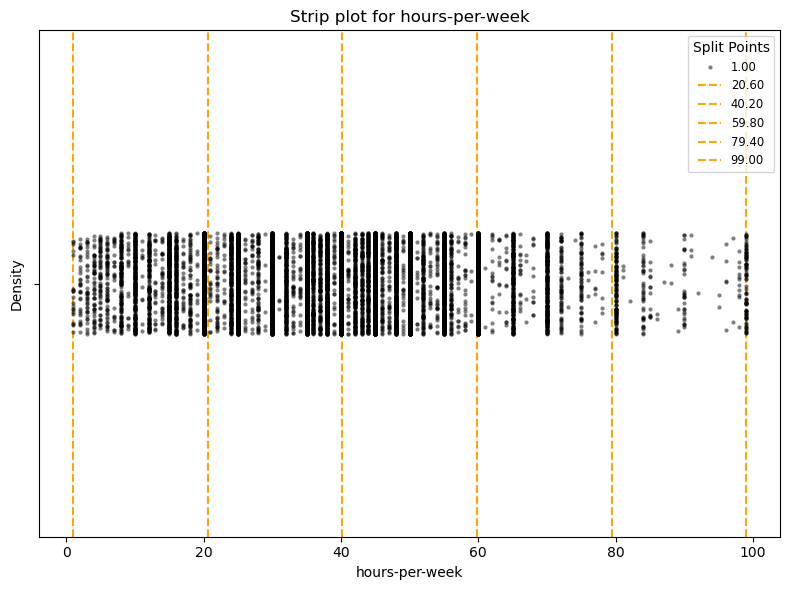

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the original dataset
data = pd.read_csv(r'C:\Users\PC\Desktop\DM-HW2-Elham_Abedi-40331562\data\adult.csv')

# Step 3.1: Handling missing values
# Replace '?' with NaN
data.replace('?', pd.NA, inplace=True)

# Columns with missing values
cols_missing = ['workclass', 'occupation', 'native-country']

# Fill missing values with mode
for col in cols_missing:
    col_mode = data[col].mode()[0]
    data[col].fillna(col_mode, inplace=True)
    print(f"Missing values in column '{col}' replaced with mode '{col_mode}'.")

# Recheck missing values
print("\nNumber of missing values after imputation:")
print(data[cols_missing].isnull().sum())

# Step 3.2: Merging infrequent countries
# Count occurrences of each country
country_freq = data['native-country'].value_counts()

# Identify rare countries (appear less than 40 times)
rare_countries = country_freq[country_freq < 40].index

# Replace rare countries with 'Others'
data['native-country'] = data['native-country'].replace(rare_countries, 'Others')

# Save the preprocessed file
output_file = '../dist/adult_to_others.csv'
data.to_csv(output_file, index=False)
print(f"\nPreprocessed dataset saved to {output_file}.")

# Count remaining unique countries
remaining_countries = data['native-country'].nunique()
print("Number of unique countries after merging:", remaining_countries)

# Step 3.3: Binarizing categorical attributes
data = pd.read_csv(output_file)

# Identify categorical columns
cat_cols = data.select_dtypes(include=['object']).columns

# Apply one-hot encoding
binarized_data = pd.get_dummies(data, columns=cat_cols, prefix_sep=' = ')

# Convert binary values to 0 and 1
binarized_data = binarized_data.astype(int)

# Rename income-related columns
if 'income = >50K' in binarized_data.columns:
    binarized_data.rename(columns={
        'income = <=50K': 'income <= 50K',
        'income = >50K': 'income > 50K'
    }, inplace=True)

# Save the binarized dataset
binarized_file = '../dist/adult_binarized.csv'
binarized_data.to_csv(binarized_file, index=False)
print(f"\nBinarized dataset saved to {binarized_file}.")

# Step 3.4: Binarizing continuous attributes
def binarize_cont_attributes(df, feature, boundaries, prefix_name):
    bin_labels = []
    
    # Generate labels based on boundaries
    for i in range(len(boundaries) - 1):
        if i == 0:
            bin_labels.append(f"{prefix_name} <= {boundaries[i+1]:.2f}")
        elif i == len(boundaries) - 2:
            bin_labels.append(f"{boundaries[i]:.2f} < {prefix_name} <= {boundaries[i+1]:.2f}")
            bin_labels.append(f"{prefix_name} > {boundaries[i+1]:.2f}")
        else:
            bin_labels.append(f"{boundaries[i]:.2f} < {prefix_name} <= {boundaries[i+1]:.2f}")
    
    # Apply binning and one-hot encoding
    df[f"{feature}_bin"] = pd.cut(df[feature], bins=boundaries, labels=bin_labels[:-1], right=True)
    
    # Create binary columns
    bin_columns = pd.get_dummies(df[f"{feature}_bin"], prefix='', prefix_sep='').reindex(columns=bin_labels, fill_value=0)
    
    # Add new columns to the dataframe
    df = pd.concat([df, bin_columns], axis=1)
    
    # Drop the original feature column
    df.drop(columns=[feature, f"{feature}_bin"], inplace=True)
    
    return df

# Process the 'age' feature with equal frequency binning
age_bounds = pd.qcut(binarized_data["age"], q=12, retbins=True, duplicates="drop")[1]
binarized_data = binarize_cont_attributes(binarized_data, "age", age_bounds, "age")

# Process the 'education-num' feature with equal width binning
edu_bounds = np.linspace(binarized_data["education-num"].min(), binarized_data["education-num"].max(), 9)
binarized_data = binarize_cont_attributes(binarized_data, "education-num", edu_bounds, "education-num")

# Process the 'capital-gain' feature with specified split points
gain_bounds = [-np.inf, 2000, 5700, 11500, 21500, 64000, np.inf]
binarized_data = binarize_cont_attributes(binarized_data, "capital-gain", gain_bounds, "capital-gain")

# Process the 'capital-loss' feature with specified split points
loss_bounds = [-np.inf, 900, 2000, 3100, np.inf]
binarized_data = binarize_cont_attributes(binarized_data, "capital-loss", loss_bounds, "capital-loss")

# Process the 'hours-per-week' feature with equal width binning
hours_bounds = np.linspace(binarized_data["hours-per-week"].min(), binarized_data["hours-per-week"].max(), 6)
binarized_data = binarize_cont_attributes(binarized_data, "hours-per-week", hours_bounds, "hours-per-week")

# Save the final binarized dataset
final_output = '../dist/adult_preprocessed.csv'
binarized_data.to_csv(final_output, index=False)
print(f"\nFinal binarized dataset saved to {final_output}.")

# Step 3.5: Plot strip charts for continuous features
original_df = pd.read_csv(r'C:\Users\PC\Desktop\DM-HW2-Elham_Abedi-40331562\data\adult.csv')

attributes = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

# Define split points
boundaries = {
    "age": pd.qcut(original_df["age"], q=12, retbins=True, duplicates="drop")[1],
    "education-num": np.linspace(original_df["education-num"].min(), original_df["education-num"].max(), 9),
    "capital-gain": [-np.inf, 2000, 5700, 11500, 21500, 64000, np.inf],
    "capital-loss": [-np.inf, 900, 2000, 3100, np.inf],
    "hours-per-week": np.linspace(original_df["hours-per-week"].min(), original_df["hours-per-week"].max(), 6),
}

# Create strip plots, one per page
for attr in attributes:
    plt.figure(figsize=(8, 6))
    
    # Create the strip plot with black points
    sns.stripplot(x=original_df[attr], jitter=True, size=3, alpha=0.5, color='black')
    
    # Add orange boundaries as vertical dashed lines
    for bound in boundaries[attr]:
        plt.axvline(x=bound, color="orange", linestyle="--")
    
    # Set title and labels
    plt.title(f"Strip plot for {attr}", fontsize=12)
    plt.xlabel(attr, fontsize=10)
    plt.ylabel("Density", fontsize=10)
    
    # Use logarithmic scale for 'capital-gain' and 'capital-loss' attributes
    if attr in ["capital-gain", "capital-loss"]:
        plt.xscale("log")
    
    # Add legend for the split points
    plt.legend([f"{bound:.2f}" for bound in boundaries[attr]], title="Split Points", loc="upper right", fontsize="small")
    
    # Show the plot
    plt.tight_layout()
    plt.show()

# Save final preprocessed dataset
binarized_data.to_csv(final_output, index=False)
